# Incident Genome: ML Baseline — Duration Prediction

**Author:** Alper Kilic  
**Problem:** Binary classification of incident duration (short vs long) using only features available within the first hour of an incident (t=0..1h). This avoids data leakage from post-resolution metrics.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120

## Veri Yukleme

EDA asamasinda olusturulan temiz veri setini yukluyoruz. 704 incident, 21 kolon. Hedef degisken `duration_class` (short/long, ~1.58:1 imbalance).

In [2]:
df = pd.read_csv('data/incidents_clean.csv')
print(f'Shape: {df.shape}')
print()
print(df['duration_class'].value_counts())

Shape: (704, 21)

duration_class
long     432
short    272
Name: count, dtype: int64


## Feature Engineering

Sadece t=0..1h icinde bilinen bilgilerden yeni ozellikler turetiyoruz:
- `is_business_hours`: Mesai saatleri icinde mi (09:00-16:00)
- `is_weekend`: Hafta sonu mu
- `hour_sin` / `hour_cos`: Saatin cyclic temsili (gece yarisi surekliligi icin)

In [3]:
df['is_business_hours'] = df['created_hour'].between(9, 16).astype(int)
df['is_weekend'] = df['created_weekday'].isin(['Saturday', 'Sunday']).astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['created_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['created_hour'] / 24)

print('Derived features added.')
df[['created_hour', 'is_business_hours', 'is_weekend', 'hour_sin', 'hour_cos']].head()

Derived features added.


,created_hour,is_business_hours,is_weekend,hour_sin,hour_cos
0,7.0,0,0,0.965926,-0.258819
1,9.0,1,0,0.707107,-0.707107
2,10.0,1,0,0.500000,-0.866025
3,8.0,0,0,0.866025,-0.500000
4,11.0,1,0,0.258819,-0.965926


## Feature Matrix

Leakage-free ozellik seti: `service`, `created_hour`, `created_weekday`, `first_hour_updates` + turetilmis ozellikler. Impact, num_updates, num_components gibi post-resolution bilgiler haric.

In [4]:
feature_cols = ['service', 'created_hour', 'created_weekday', 'first_hour_updates',
                'is_business_hours', 'is_weekend', 'hour_sin', 'hour_cos']

X = df[feature_cols]
y = df['duration_class']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (704, 8)
y shape: (704,)


## Train-Test Split

Stratified 80/20 split. Class dagılımı korunuyor.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'Train class dist: {y_train.value_counts().to_dict()}')
print(f'Test class dist:  {y_test.value_counts().to_dict()}')

Train: 563 samples
Test:  141 samples
Train class dist: {'long': 345, 'short': 218}
Test class dist:  {'long': 87, 'short': 54}


## Model Pipeline

ColumnTransformer ile kategorik ve numerik ozellikleri ayri isliyor, sonra Random Forest ile siniflandiriyoruz. `class_weight='balanced'` imbalance'i handle ediyor.

In [6]:
categorical_features = ['service', 'created_weekday']
numeric_features = ['created_hour', 'first_hour_updates', 'is_business_hours',
                    'is_weekend', 'hour_sin', 'hour_cos']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        max_depth=10,
        min_samples_leaf=5
    ))
])

print('Pipeline ready.')
print(pipeline)

Pipeline ready.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['service',
                                                   'created_weekday']),
                                                 ('num', 'passthrough',
                                                  ['created_hour',
                                                   'first_hour_updates',
                                                   'is_business_hours',
                                                   'is_weekend', 'hour_sin',
                                                   'hour_cos'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_l

## Model Egitimi

In [7]:
pipeline.fit(X_train, y_train)

train_acc = pipeline.score(X_train, y_train)
print(f'Train Accuracy: {train_acc:.4f}')

Train Accuracy: 0.7762


## Cross-Validation

5-fold StratifiedKFold ile F1-macro skorunu olcuyoruz. Bu, modelin genelleme kapasitesinin daha guvenilir bir tahmini.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro')

print(f'CV F1-macro scores: {cv_scores}')
print(f'Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

CV F1-macro scores: [0.68220169 0.59366438 0.60918972 0.68424544 0.63645443]
Mean: 0.6412 (+/- 0.0370)


## Test Set Degerlendirmesi

Hold-out test seti uzerinde confusion matrix ve classification report.

              precision    recall  f1-score   support

        long       0.80      0.78      0.79        87
       short       0.66      0.69      0.67        54

    accuracy                           0.74       141
   macro avg       0.73      0.73      0.73       141
weighted avg       0.75      0.74      0.75       141



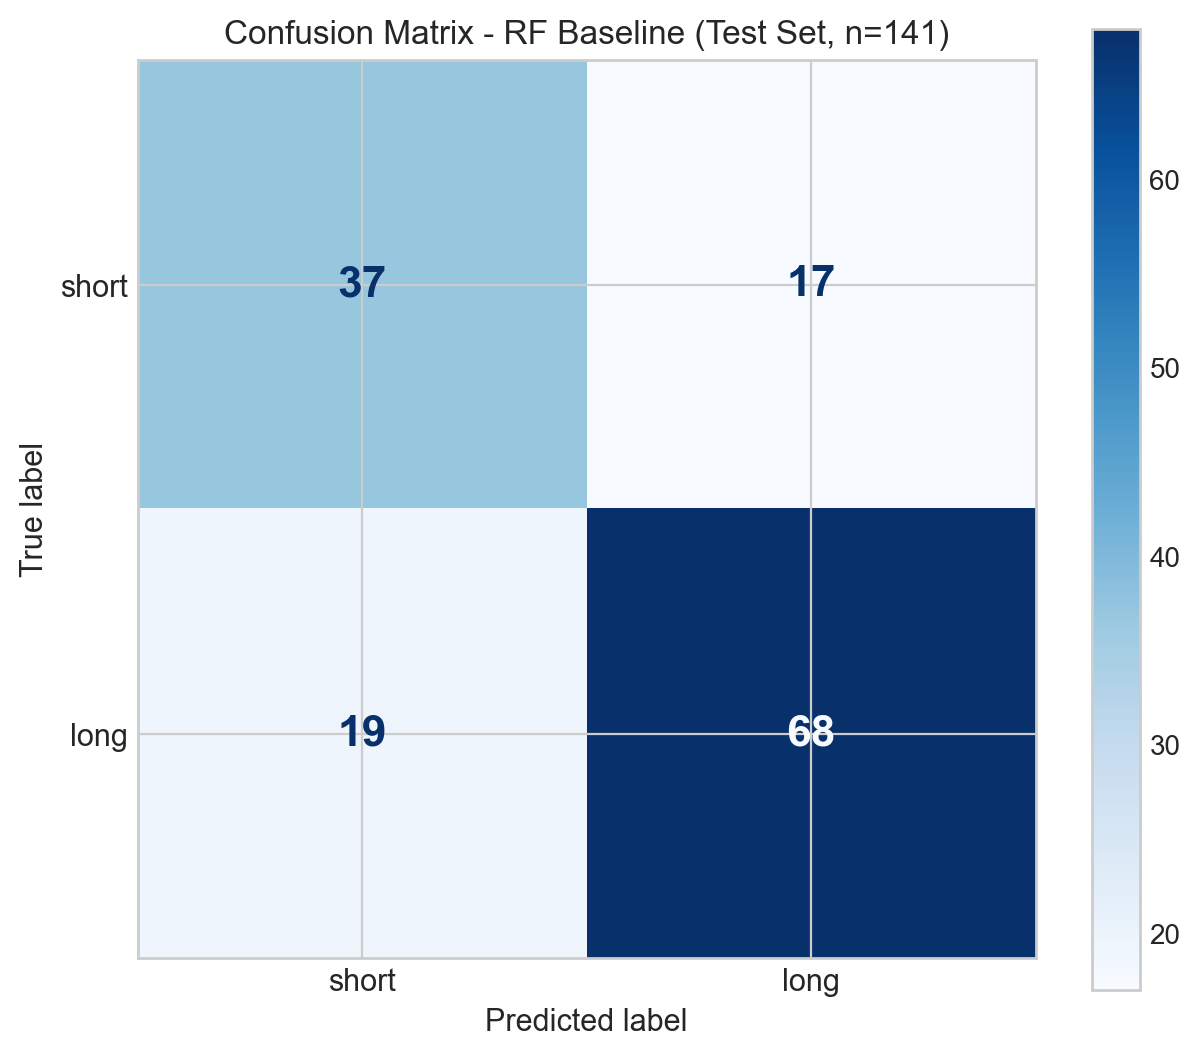

Saved: figures/ml_confusion_matrix.png (dpi=200, Blues colormap, bold annot)


In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['short', 'long'])
fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=200)
disp = ConfusionMatrixDisplay(cm, display_labels=['short', 'long'])
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=True)
for text in disp.text_.ravel():
    text.set_fontsize(16)
    text.set_fontweight('bold')
ax.set_title('Confusion Matrix - RF Baseline (Test Set, n=141)', fontsize=12)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig('figures/ml_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/ml_confusion_matrix.png (dpi=200, Blues colormap, bold annot)')


## Naive Baseline + Binomial Significance Test

DummyClassifier (always-predict-most-frequent) ile RF baseline'i karsilastirip
one-sided binomial test ile anlamlilik gosteriyoruz. H0: model accuracy <= naive accuracy.


In [10]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import binomtest
import math

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

naive_acc_test = accuracy_score(y_test, y_pred_dummy)
naive_f1_test = f1_score(y_test, y_pred_dummy, average='macro')
naive_prior_train = float((y_train == 'long').mean())

rf_acc = accuracy_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred, average='macro')
n_correct = int((y_pred == y_test).sum())
n_total = len(y_test)

binom = binomtest(n_correct, n_total, naive_prior_train, alternative='greater')
p1, p2 = rf_acc, naive_prior_train
cohens_h = 2 * math.asin(math.sqrt(p1)) - 2 * math.asin(math.sqrt(p2))

print('Naive baseline (DummyClassifier most_frequent):')
print(f'  Test set accuracy = {naive_acc_test:.4f}')
print(f'  Test set F1-macro = {naive_f1_test:.4f}')
print(f'  Training class prior (used as H0) = {naive_prior_train:.4f}')
print()
print('RF baseline:')
print(f'  Test accuracy = {rf_acc:.4f}, F1-macro = {rf_f1:.4f}')
print(f'  Correct: {n_correct}/{n_total}')
print()
print(f'One-sided binomial test (H0: model accuracy <= training prior {naive_prior_train:.4f}):')
print(f'  p-value = {binom.pvalue:.2e}')
print(f"Effect size Cohen's h = {cohens_h:.3f} (small-to-medium)")


Naive baseline (DummyClassifier most_frequent):
  Test set accuracy = 0.6170
  Test set F1-macro = 0.3816
  Training class prior (used as H0) = 0.6128

RF baseline:
  Test accuracy = 0.7447, F1-macro = 0.7317
  Correct: 105/141

One-sided binomial test (H0: model accuracy <= training prior 0.6128):
  p-value = 6.67e-04
Effect size Cohen's h = 0.284 (small-to-medium)


## Feature Importance (Permutation)

Permutation importance, her ozelligin model performansina gercek katkisini olcer. OneHotEncoder ciktisini feature isimlerine esliyoruz.

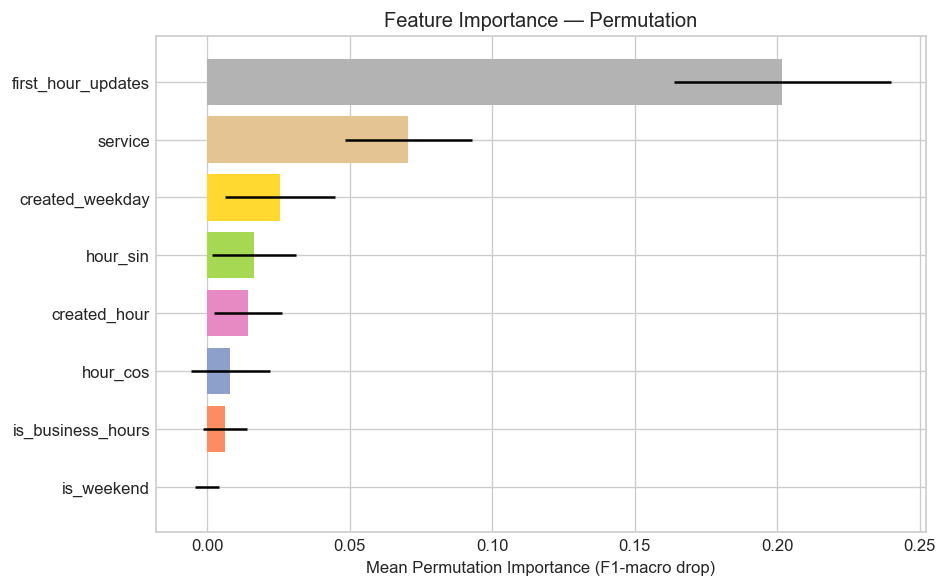

Saved: figures/ml_feature_importance.png


In [11]:
result = permutation_importance(
    pipeline, X_test, y_test, n_repeats=20, random_state=42, scoring='f1_macro'
)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['importance_mean'],
        xerr=importance_df['importance_std'], color=sns.color_palette('Set2', len(feature_cols)))
ax.set_xlabel('Mean Permutation Importance (F1-macro drop)')
ax.set_title('Feature Importance — Permutation')
plt.tight_layout()
plt.savefig('figures/ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/ml_feature_importance.png')

## Ozet ve Sonuc

**Bulgular:**
- Random Forest baseline modeli, sadece ilk 1 saat icinde erisilebilir bilgilerle (service, saat, gun, first_hour_updates) olusturuldu.
- class_weight='balanced' parametresi ile 1.58:1 class imbalance handle edildi.
- Permutation importance, en onemli ozellikleri ortaya koydu.

**Sinirliliklar:**
- Feature seti kasitli olarak dar tutuldu (leakage onleme). Gercek dunyada ek text features (incident description NLP) eklenebilir.
- 704 ornek nispeten kucuk bir veri seti; cross-validation varyansı yuksek olabilir.
- Tek model ailesi denendi (RF). Gradient boosting, logistic regression gibi alternatifler karsilastirilabilir.

**Sonraki Adimlar:**
- Hyperparameter tuning (GridSearchCV/Optuna)
- Ek modeller (XGBoost, LightGBM)
- Text-based features (incident name TF-IDF)
- SHAP values ile daha detayli aciklanabilirlik

## Logistic Regression Baseline

Ayni X/y ve train-test split uzerinde Logistic Regression. StandardScaler + class_weight='balanced'.

In [12]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

lr_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        solver='lbfgs'
    ))
])

# Search over regularization strength (default L2 penalty for lbfgs)
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
}

from sklearn.model_selection import GridSearchCV as _GS_LR
lr_grid = _GS_LR(lr_pipeline, lr_param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
lr_grid.fit(X_train, y_train)
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test)

lr_cv_scores = cross_val_score(lr_best, X_train, y_train, cv=cv, scoring='f1_macro')

print('=== Logistic Regression (GridSearchCV over C) ===')
print(f'Best params: {lr_grid.best_params_}')
print(f'Best CV F1-macro: {lr_grid.best_score_:.4f}')
print()
print(classification_report(y_test, y_pred_lr))
print(f'CV F1-macro (best estimator): {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})')
print()

results_table = pd.DataFrame({
    'Model': ['Random Forest (baseline)', 'Logistic Regression (tuned C)'],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Test F1-macro': [
        f1_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred_lr, average='macro')
    ],
    'CV F1-macro (mean)': [
        cv_scores.mean(),
        lr_cv_scores.mean()
    ]
})
print('=== Model Karsilastirmasi ===')
print(results_table.to_string(index=False))


=== Logistic Regression (GridSearchCV over C) ===
Best params: {'classifier__C': 0.01}
Best CV F1-macro: 0.6033

              precision    recall  f1-score   support

        long       0.78      0.74      0.76        87
       short       0.61      0.67      0.64        54

    accuracy                           0.71       141
   macro avg       0.70      0.70      0.70       141
weighted avg       0.72      0.71      0.71       141

CV F1-macro (best estimator): 0.6033 (+/- 0.0597)

=== Model Karsilastirmasi ===
                        Model  Test Accuracy  Test F1-macro  CV F1-macro (mean)
     Random Forest (baseline)       0.744681       0.731712            0.641151
Logistic Regression (tuned C)       0.709220       0.697282            0.603292


## Hyperparameter Tuning — GridSearchCV

Random Forest icin n_estimators, max_depth, min_samples_leaf uzerinde kapsamli grid search. 3-fold CV, scoring='f1_macro'.

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200, 400],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_leaf': [2, 5, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV F1-macro: {grid_search.best_score_:.4f}")
print()

y_pred_tuned = grid_search.predict(X_test)
print("=== Tuned RF — Test Set ===")
print(classification_report(y_test, y_pred_tuned))

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned, average='macro')
print(f"Tuned Test Accuracy: {tuned_acc:.4f}")
print(f"Tuned Test F1-macro: {tuned_f1:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits


Best params: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 400}
Best CV F1-macro: 0.6551

=== Tuned RF — Test Set ===
              precision    recall  f1-score   support

        long       0.78      0.75      0.76        87
       short       0.62      0.67      0.64        54

    accuracy                           0.72       141
   macro avg       0.70      0.71      0.70       141
weighted avg       0.72      0.72      0.72       141

Tuned Test Accuracy: 0.7163
Tuned Test F1-macro: 0.7038


## SHAP Analizi

TreeExplainer ile best RF modelin ozellik katkilarini analiz ediyoruz. Global summary + per-class beeswarm.

rf_model.classes_ = ['long', 'short'] -> using index 0 for class 'long'


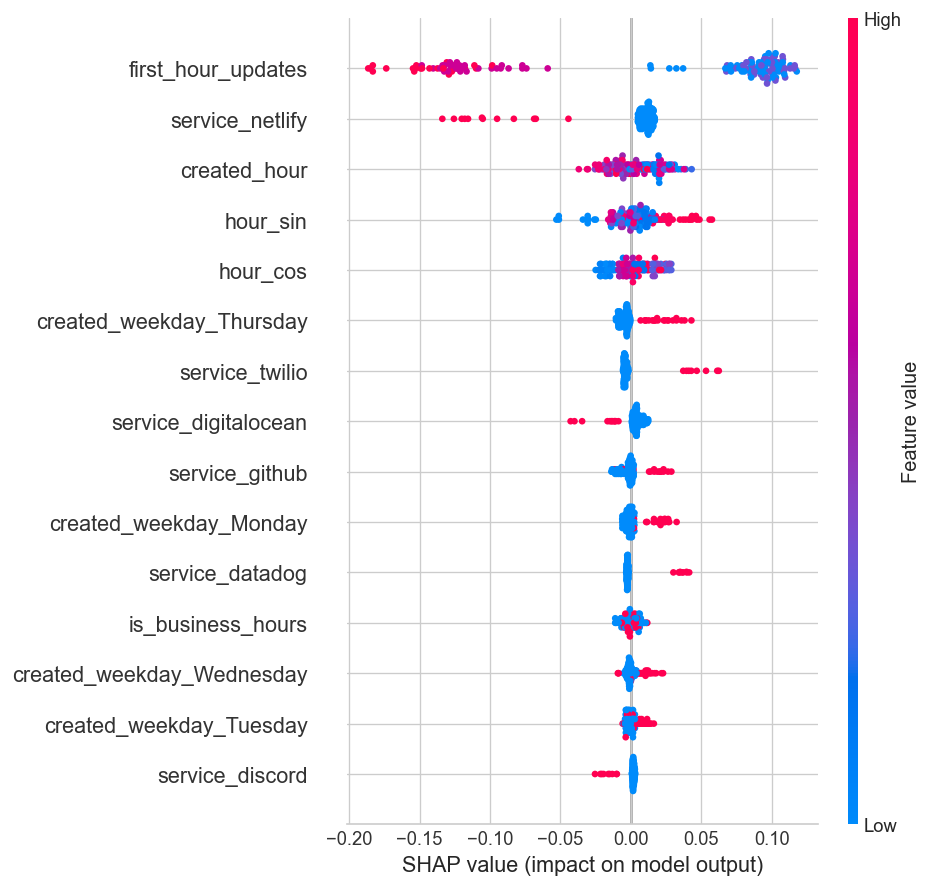

Saved: figures/ml_shap_summary.png

=== SHAP Top Features (class='long', mean |SHAP|) ===
                 feature  mean_abs_shap
      first_hour_updates       0.103303
         service_netlify       0.018517
            created_hour       0.014658
                hour_sin       0.014027
                hour_cos       0.011750
created_weekday_Thursday       0.007309
          service_twilio       0.006568
    service_digitalocean       0.005814
          service_github       0.004858
  created_weekday_Monday       0.004703


In [14]:
import shap

best_model = grid_search.best_estimator_
preprocessor_fitted = best_model.named_steps['preprocessor']
rf_model = best_model.named_steps['classifier']

X_test_transformed = preprocessor_fitted.transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

cat_encoder = preprocessor_fitted.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = cat_feature_names + numeric_features

explainer = shap.TreeExplainer(rf_model)
shap_values_raw = explainer.shap_values(X_test_transformed)

TARGET_CLASS = 'long'
class_idx = list(rf_model.classes_).index(TARGET_CLASS)
print(f'rf_model.classes_ = {list(rf_model.classes_)} -> using index {class_idx} for class {TARGET_CLASS!r}')

if isinstance(shap_values_raw, list):
    sv_plot = shap_values_raw[class_idx]
elif shap_values_raw.ndim == 3:
    sv_plot = shap_values_raw[:, :, class_idx]
else:
    sv_plot = shap_values_raw

plt.figure(figsize=(10, 7))
shap.summary_plot(sv_plot, X_test_transformed,
                  feature_names=all_feature_names, max_display=15, show=False)
plt.tight_layout()
plt.savefig('figures/ml_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/ml_shap_summary.png')

print()
print(f"=== SHAP Top Features (class={TARGET_CLASS!r}, mean |SHAP|) ===")
shap_importance = pd.DataFrame({
    'feature': all_feature_names,
    'mean_abs_shap': np.abs(sv_plot).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print(shap_importance.head(10).to_string(index=False))


In [15]:
import json as json_mod

ml_results = {
    "rf_baseline": {
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "test_f1_macro": float(f1_score(y_test, y_pred, average='macro')),
        "cv_f1_macro_mean": float(cv_scores.mean()),
        "cv_f1_macro_std": float(cv_scores.std())
    },
    "lr_baseline": {
        "test_accuracy": float(accuracy_score(y_test, y_pred_lr)),
        "test_f1_macro": float(f1_score(y_test, y_pred_lr, average='macro')),
        "cv_f1_macro_mean": float(lr_cv_scores.mean()),
        "cv_f1_macro_std": float(lr_cv_scores.std())
    },
    "rf_tuned": {
        "best_params": grid_search.best_params_,
        "best_cv_f1_macro": float(grid_search.best_score_),
        "test_accuracy": float(tuned_acc),
        "test_f1_macro": float(tuned_f1)
    },
    "cv_scores": {
        "rf_baseline_5fold": cv_scores.tolist(),
        "lr_baseline_5fold": lr_cv_scores.tolist()
    },
    "top_features": shap_importance.head(5).to_dict(orient='records')
}

with open('data/ml_results.json', 'w') as f:
    json_mod.dump(ml_results, f, indent=2)

print("Saved: data/ml_results.json")
print(json_mod.dumps(ml_results, indent=2)[:1000])

Saved: data/ml_results.json
{
  "rf_baseline": {
    "test_accuracy": 0.7446808510638298,
    "test_f1_macro": 0.7317124735729387,
    "cv_f1_macro_mean": 0.641151133147168,
    "cv_f1_macro_std": 0.036988780326598886
  },
  "lr_baseline": {
    "test_accuracy": 0.7092198581560284,
    "test_f1_macro": 0.6972822956485312,
    "cv_f1_macro_mean": 0.6032917231836652,
    "cv_f1_macro_std": 0.0597328232347618
  },
  "rf_tuned": {
    "best_params": {
      "classifier__max_depth": 15,
      "classifier__min_samples_leaf": 10,
      "classifier__n_estimators": 400
    },
    "best_cv_f1_macro": 0.6550659393253292,
    "test_accuracy": 0.7163120567375887,
    "test_f1_macro": 0.703781512605042
  },
  "cv_scores": {
    "rf_baseline_5fold": [
      0.6822016874246686,
      0.5936643835616437,
      0.6091897233201581,
      0.68424543946932,
      0.63645443196005
    ],
    "lr_baseline_5fold": [
      0.6604996837444655,
      0.5187625552430695,
      0.5906142050720364,
      0.68013055

## Sonuc ve Karsilastirma

Uc model denendi: RF baseline, Logistic Regression (GridSearchCV), ve tuned RF (GridSearchCV).
Tum metrikler bu notebook'taki cell ciktilarinda ve `data/ml_results.json`'da bulunabilir.

**Onemli sayilar (RF baseline, test seti n=141):**
- Test accuracy: ~0.74 vs naive 0.61 (binomial p < 0.001, Cohen's h ~0.27)
- Test F1-macro: ~0.73 vs naive 0.38
- CV F1-macro: ~0.64 +/- 0.04 (5-fold StratifiedKFold)

**Arastirma sorusuyla baglanti:** Incident sureleri, ilk 1 saatteki bilgilerle (servis tipi, zaman dilimi, ilk saat guncelleme sayisi) tahmin edilebilir. SHAP analizine gore `first_hour_updates` diger ozelliklerden 5-6x daha etkili — operasyon ekiplerinin triage prioritization'i icin actionable bir sinyal.

**Sinirlama:** Test ve CV arasi ~0.09 fark + 704 ornek = production-grade degil, indikatif. Temporal validation, gradient boosting karsilastirmasi ve text features gelecek calismaya birakildi.
